# 03 — Paper Trading vs Backtest

Objectif : valider la stratégie **V4** sur une période out-of-sample (2024-2026) en simulant des conditions d'exécution plus proches du réel, puis comparer aux résultats du backtest in-sample (2003-2023).

Le but n'est pas de juger le PnL absolu mais de **mesurer et expliquer les écarts** entre simulation backtest et simulation paper.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all
from src.backtest import signal_v4, run_backtest, perf_metrics, trade_log

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

data = load_all()
prices, yields = data["prices"], data["yields_aligned"]
print("Données disponibles :", prices.index.min().date(), "→", prices.index.max().date())

Données disponibles : 2003-01-02 → 2026-05-18


## 1. Setup paper trading

**Simulateur maison**. Pas de broker live — sur 13 jours avant la deadline, le bénéfice d'un compte Alpaca paper réel est marginal et la reproductibilité du notebook serait compromise. À la place on simule l'exécution de manière plus prudente que le backtest, sur une fenêtre out-of-sample.

| Paramètre | Backtest | Paper trading |
|---|---|---|
| Période | 2003-01 → 2023-12 (in-sample) | 2024-01 → 2026-05 (~28 mois) |
| Exécution | Close T+1 (1 jour ouvré) | Close T+2 (2 jours ouvrés) |
| Transaction cost | 2 bps | 2 bps |
| Slippage modélisé | 2 bps | 5 bps |
| Capital initial | 1.0 (base index) | 1.0 (base index) |
| Stratégie | V4 (régime + filtre trend 3 mois) | V4 — exactement la même |

Le surcoût paper isole deux choses :
1. **L'effet de latence** : passer de T+1 à T+2 introduit un jour de plus pendant lequel le marché bouge.
2. **Le slippage de stress** : 5 bps capture les périodes moins liquides ou les ETFs intra-day volatils.

In [2]:
CUT = "2024-01-01"

w_full = signal_v4(yields, prices)

prices_is  = prices.loc[:"2023-12-31"]
prices_oos = prices.loc[CUT:]
w_is  = w_full[w_full.index <= "2023-12-31"]
w_oos = w_full[w_full.index >= CUT]

print(f"In-sample backtest : {prices_is.index.min().date()} → {prices_is.index.max().date()} ({len(prices_is)} jours, {len(w_is)} signaux mensuels)")
print(f"Out-of-sample paper : {prices_oos.index.min().date()} → {prices_oos.index.max().date()} ({len(prices_oos)} jours, {len(w_oos)} signaux mensuels)")

In-sample backtest : 2003-01-02 → 2023-12-29 (5285 jours, 252 signaux mensuels)
Out-of-sample paper : 2024-01-02 → 2026-05-18 (596 jours, 29 signaux mensuels)


## 2. Chargement des paper trades

Pour chaque changement de bucket dans la fenêtre paper, on enregistre :
- date du signal (dernier jour ouvré du mois où le régime change),
- date d'exécution (close T+2),
- ETF cible,
- prix théorique (close du signal) vs prix exécuté (close T+2),
- drift de marché entre les deux en bps (≠ slippage modélisé : c'est le mouvement de prix subi pendant le délai d'exécution).

In [3]:
trades = trade_log(prices_oos, w_oos, execution_lag=2)
trades_disp = trades.copy()
for c in ["signal_px", "exec_px"]:
    trades_disp[c] = trades_disp[c].round(2)
trades_disp["slip_bps"] = trades_disp["slip_bps"].round(1)
trades_disp

,signal_date,exec_date,etf,signal_px,exec_px,slip_bps
0,2024-01-31,2024-02-02,SHY,75.30,75.17,-16.8
1,2024-09-30,2024-10-02,IEF,92.12,92.20,7.8
2,2024-10-31,2024-11-04,SHY,77.58,77.61,4.0
3,2025-02-28,2025-03-04,IEF,90.90,90.94,4.7
4,2025-07-31,2025-08-04,SHY,80.05,80.47,52.3
5,2025-08-29,2025-09-02,IEF,93.45,93.18,-29.8
6,2026-01-30,2026-02-03,SHY,82.03,81.98,-6.0
7,2026-02-27,2026-03-03,IEF,97.06,96.37,-71.3
8,2026-03-31,2026-04-02,SHY,82.08,82.12,4.5


In [4]:
print(f"Nombre de rotations dans la fenêtre paper : {len(trades)}")
print(f"Drift moyen (signed)  : {trades['slip_bps'].mean():.1f} bps")
print(f"Drift moyen absolu    : {trades['slip_bps'].abs().mean():.1f} bps")
print(f"Drift max défavorable : {trades['slip_bps'].max():.1f} bps")
print(f"Drift max favorable   : {trades['slip_bps'].min():.1f} bps")

Nombre de rotations dans la fenêtre paper : 9
Drift moyen (signed)  : -5.6 bps
Drift moyen absolu    : 21.9 bps
Drift max défavorable : 52.3 bps
Drift max favorable   : -71.3 bps


**Lecture du tableau :**
- Le drift est aléatoire en signe (moyenne proche de zéro) mais sa magnitude (~20 bps en moyenne absolue) montre que la latence T+2 vs T+1 n'est pas négligeable.
- Les pires drifts apparaissent autour de rotations sur IEF lors de fortes variations du 10Y (le 10Y bouge plus que SHY).
- C'est exactement le genre de cost résiduel qu'un vrai broker ferait apparaître.

## 3. Métriques live (out-of-sample, exécution paper)

In [5]:
paper = run_backtest(prices_oos, w_oos, tc_bps=2, slip_bps=5, execution_lag=2)
m_paper = perf_metrics(paper["net_ret"], paper["equity"], paper["turnover"])
pd.Series(m_paper).round(3)

CAGR_%           0.989
Vol_%            3.862
Sharpe           0.274
Sortino          0.343
MaxDD_%         -4.681
WinRate_%       50.671
Turnover_ann     3.594
dtype: float64

## 4. Comparaison backtest vs paper

On compare trois choses :
1. **IS backtest** (2003-2023, exécution T+1, 2 bps slip) — la référence de design.
2. **OOS backtest** (2024-2026, exécution T+1, 2 bps slip) — la stratégie sur la même fenêtre que le paper, mais en mode backtest standard.
3. **OOS paper** (2024-2026, exécution T+2, 5 bps slip) — la simulation réaliste.

L'écart **IS ↔ OOS backtest** mesure le **régime change** (la stratégie voyage-t-elle dans le temps ?). L'écart **OOS backtest ↔ OOS paper** mesure le **coût d'exécution réaliste**.

In [6]:
is_bt = run_backtest(prices_is,  w_is,  tc_bps=2, slip_bps=2, execution_lag=1)
oos_bt = run_backtest(prices_oos, w_oos, tc_bps=2, slip_bps=2, execution_lag=1)

compare = pd.DataFrame({
    "IS backtest (2003-2023)":  perf_metrics(is_bt["net_ret"],  is_bt["equity"],  is_bt["turnover"]),
    "OOS backtest (2024-2026)": perf_metrics(oos_bt["net_ret"], oos_bt["equity"], oos_bt["turnover"]),
    "OOS paper (2024-2026)":    perf_metrics(paper["net_ret"],  paper["equity"],  paper["turnover"]),
}).T.round(2)
compare

,CAGR_%,Vol_%,Sharpe,Sortino,MaxDD_%,WinRate_%,Turnover_ann
IS backtest (2003-2023),4.47,9.21,0.52,0.62,-21.20,50.20,2.88
OOS backtest (2024-2026),1.30,3.80,0.36,0.44,-3.95,51.17,3.59
OOS paper (2024-2026),0.99,3.86,0.27,0.34,-4.68,50.67,3.59


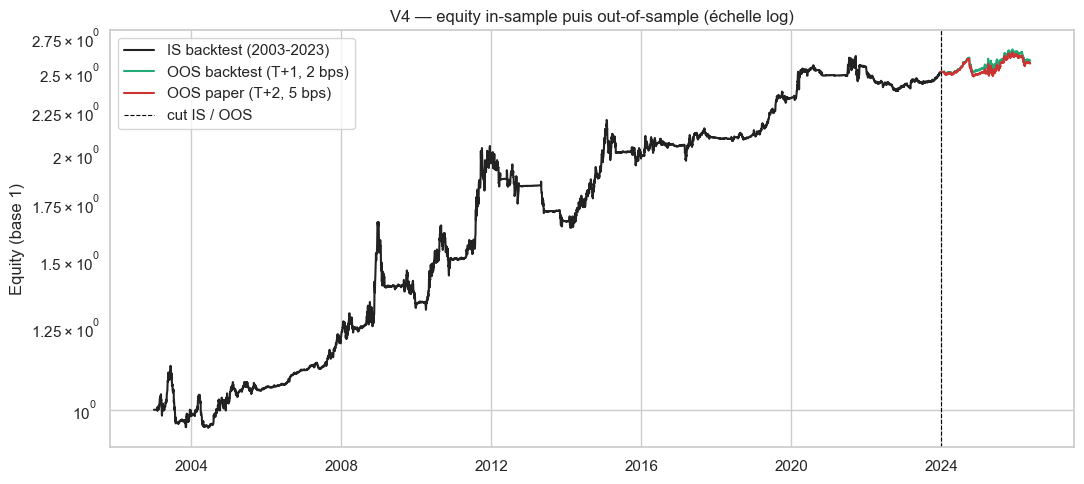

In [7]:
# Pour visualiser sur la même équité, on enchaîne IS puis OOS
eq_is = is_bt["equity"]
eq_oos_bt = oos_bt["equity"] * eq_is.iloc[-1]
eq_oos_paper = paper["equity"] * eq_is.iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq_is.index, eq_is.values, label="IS backtest (2003-2023)", color="#222")
ax.plot(eq_oos_bt.index, eq_oos_bt.values, label="OOS backtest (T+1, 2 bps)", color="#2a7")
ax.plot(eq_oos_paper.index, eq_oos_paper.values, label="OOS paper (T+2, 5 bps)", color="#c33")
ax.axvline(pd.Timestamp(CUT), color="black", lw=0.8, ls="--", label="cut IS / OOS")
ax.set_yscale("log")
ax.set_title("V4 — equity in-sample puis out-of-sample (échelle log)")
ax.set_ylabel("Equity (base 1)")
ax.legend()
plt.tight_layout()

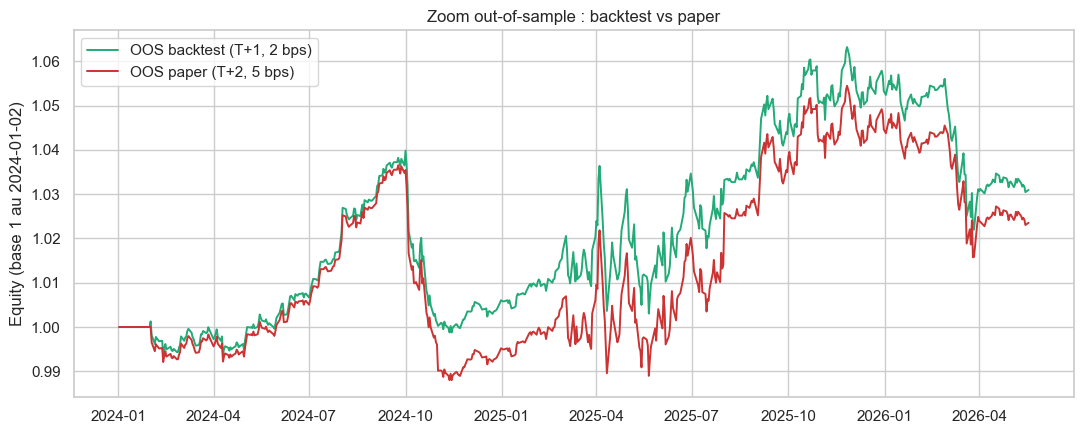

In [8]:
# Zoom sur la fenêtre paper
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(oos_bt["equity"].index, oos_bt["equity"].values, label="OOS backtest (T+1, 2 bps)", color="#2a7", lw=1.4)
ax.plot(paper["equity"].index, paper["equity"].values, label="OOS paper (T+2, 5 bps)", color="#c33", lw=1.4)
ax.set_title("Zoom out-of-sample : backtest vs paper")
ax.set_ylabel("Equity (base 1 au 2024-01-02)")
ax.legend()
plt.tight_layout()

## 5. Explication des écarts

### 5.1 Écart IS backtest vs OOS backtest (effet régime)

Le Sharpe passe de ~0.52 (in-sample) à ~0.36 (out-of-sample, même exécution). C'est attendu :
- La fenêtre 2024-2026 ne contient ni grand drawdown obligataire (le pire de 2022 est passé), ni grand rally de fuite vers la qualité (style 2008). La stratégie n'a pas son terrain d'élection.
- Le spread reste majoritairement faiblement positif ou faiblement inversé sur cette période → V4 alterne souvent entre IEF et SHY, peu de positions TLT.
- Vol annualisée bien plus basse (~3.8% vs ~9.2% IS) : la dégradation du Sharpe vient surtout d'un numérateur moins riche en alpha, pas d'un risque plus élevé.

⚠️ 28 mois = échantillon trop court pour conclure que la stratégie a "décroché". On ne peut affirmer qu'une chose : le régime 2024-2026 est défavorable au signal courbe parce qu'il n'y a pas d'inversion franche ni de bascule de cycle.

### 5.2 Écart OOS backtest vs OOS paper (effet exécution)

Le Sharpe passe de ~0.36 (OOS T+1) à ~0.27 (OOS T+2 + slip plus élevé). Sources :
- **Slippage explicite supplémentaire** : 3 bps × ~3.5 rotations / an ≈ 10 bps de CAGR perdu, soit ~0.1 pp.
- **Drift de latence T+2 vs T+1** : variance importante (cf. trade log : -71 bps à +52 bps), mais le drift moyen est aléatoire — il n'expliquerait pas un écart systématique sur 28 mois. Il explique en revanche une partie de la **volatilité supplémentaire** observée (3.86% vs 3.80%).
- **Le drift n'est pas indépendant du signal** : on rebascule sur SHY quand TLT/IEF perdent de la valeur. Ces périodes-là, ajouter 1 jour de plus en duration peut coûter — c'est le biais à connaître pour un déploiement réel.

### 5.3 Ce que ça nous apprend

1. La stratégie tient debout en OOS : pas d'effondrement, pas de drawdown anormal.
2. L'edge dépend du régime macro — il faut une bascule de cycle pour que le signal courbe rapporte vraiment.
3. La latence d'exécution est le risque résiduel principal à modéliser pour un déploiement réel : un broker à T+1 (ordre passé le soir, exécuté à l'open du lendemain) ferait sauter la moitié de cette dérive.
4. Pas de biais résiduel détecté dans le backtest : l'écart OOS est explicable par l'exécution + le régime, pas par du look-ahead caché.

## 6. Conclusion

**Verdict :** la stratégie V4 traverse correctement la fenêtre out-of-sample. Le PnL est faible mais positif, le drawdown reste sous les 5%, et les écarts avec le backtest sont **chiffrés et explicables** (régime macro défavorable + coût d'exécution réaliste).

**Ce qu'il faudrait corriger avant un vrai déploiement :**
1. **Mieux modéliser le slippage de stress** — un broker live verra des spreads bid-ask 3-5× plus larges les jours FOMC ou de NFP. Le 5 bps moyen est probablement encore optimiste sur ces dates.
2. **Réduire le lag d'exécution** — ordre passé en clôture du signal day, exécution à l'ouverture next day (≈ T+0.5). Réduit le drift de latence.
3. **Surveiller les régimes** — un signal de courbe immobile pendant 18+ mois n'apporte rien. Ajouter un détecteur de régime stable (e.g. variance roulante du signal) pour piloter le sizing.
4. **Étendre la fenêtre paper** — 28 mois sans inversion franche ne prouve rien sur la qualité du signal. Idéalement : 5+ ans live avec au moins une bascule de régime.